# Assignment 2: Build a CNN for image recognition.

## Due Date:  March 24, 11:59PM

### Name: Palak Sood


## Introduction:

1. In this assignment, you will build Convolutional Neural Network to classify CIFAR-10 Images.
2. You can directly load dataset from many deep learning packages.
3. You can use any deep learning packages such as pytorch, keras or tensorflow for this assignment.

## Requirements:

1. You need to load cifar 10 data and split the entire training dataset into training and validation.
2. You will implement a CNN model to classify cifar 10 images with provided structure.
3. You need to plot the training and validation accuracy or loss obtained from above step.
4. Then you can use tuned parameters to train using the entire training dataset.
5. You should report the testing accuracy using the model with complete data.
6. You may try to change the structure (e.g, add BN layer or dropout layer,...) and analyze your findings.

## Google Colab

- If you do not have GPU, the training of a CNN can be slow. Google Colab is a good option.

## Batch Normalization (BN)

### Background:

- Batch Normalization is a technique to speed up training and help make the model more stable.
- In simple words, batch normalization is just another network layer that gets inserted between a hidden layer and the next hidden layer. Its job is to take the outputs from the first hidden layer and normalize them before passing them on as the input of the next hidden layer.

- For more detailed information, you may refer to the original paper: https://arxiv.org/pdf/1502.03167.pdf.

### BN Algorithm:

- Input: Values of $x$ over a mini-batch: $\mathbf{B}$ = $\{x_1,..., x_m\};$
- Output: $\{y_i = BN_{\gamma,\beta}(x_i)\}$, $\gamma, \beta$ are learnable parameters

Normalization of the Input:
$$\mu_{\mathbf{B}} = \frac{1}{m}\sum_{i=1}^m x_i$$
$$\sigma_{\mathbf{B}}^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_{\mathbf{B}})^2$$
$$\hat{x_i} = \frac{x_i - \mu_{\mathbf{B}}}{\sqrt{\sigma_{\mathbf{B}}}^2 + \epsilon}$$
Re-scaling and offsetting:
$$y_i = \gamma \hat{x_i} + \beta = BN_{\gamma,\beta}(x_i)$$


### Advantages of BN:
1. Improves gradient flow through the network.
2. Allows use of saturating nonlinearities and higher learning rates.
3. Makes weights easier to initialize.
4. Act as a form of regularization and may reduce the need for dropout.

### Implementation:

- The batch normalization layer has already been implemented in many packages. You may simply call the function to build the layer.
- The location of BN layer: Please make sure ```BatchNormalization``` is between a ```Conv```/```Dense``` layer and an ```activation``` layer.

## 1. Data preparation

### 1.1. Load data


In [1]:
import keras
from keras.datasets import cifar10
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout
from keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
# Load Cifar-10 Data
# This is just an example, you may load dataset from other packages.


(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print('shape of x_train: ' + str(x_train.shape))
print('shape of y_train: ' + str(y_train.shape))
print('shape of x_test: ' + str(x_test.shape))
print('shape of y_test: ' + str(y_test.shape))
print('number of classes: ' + str(np.max(y_train) - np.min(y_train) + 1))

shape of x_train: (50000, 32, 32, 3)
shape of y_train: (50000, 1)
shape of x_test: (10000, 32, 32, 3)
shape of y_test: (10000, 1)
number of classes: 10


### 1.2. One-hot encode the labels (5 points)

In the input, a label is a scalar in $\{0, 1, \cdots , 9\}$. One-hot encoding transforms such a scalar to a $10$-dim vector. E.g., a scalar ```y_train[j]=3``` is transformed to the vector ```y_train_vec[j]=[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]```.

1. Implement a function ```to_one_hot``` that transforms an $n\times 1$ array to a $n\times 10$ matrix.

2. Apply the function to ```y_train``` and ```y_test```.

#### Remark: the outputs should be
* Shape of y_train_vec: (50000, 10)
* Shape of y_test_vec: (10000, 10)
* [6]
* [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

In [3]:
def to_one_hot(y, num_class=10):
    encode = np.zeros((len(y), num_class))
    for i, label in enumerate(y):
        encode[i,label] = 1
    return encode

y_train_vec = to_one_hot(y_train)
y_test_vec = to_one_hot(y_test)

print('Shape of y_train_vec: ' + str(y_train_vec.shape))
print('Shape of y_test_vec: ' + str(y_test_vec.shape))

print(y_train[0])
print(y_train_vec[0])

Shape of y_train_vec: (50000, 10)
Shape of y_test_vec: (10000, 10)
[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


### 1.3. Randomly partition the training set to training and validation sets (5 points)

Randomly partition the 50K training samples to 2 sets:
* a training set containing 40K samples: x_tr, y_tr
* a validation set containing 10K samples: x_val, y_val


In [4]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train_vec, test_size=10000, random_state=0)

print('Shape of x_tr: ' + str(x_tr.shape))
print('Shape of y_tr: ' + str(y_tr.shape))
print('Shape of x_val: ' + str(x_val.shape))
print('Shape of y_val: ' + str(y_val.shape))

Shape of x_tr: (40000, 32, 32, 3)
Shape of y_tr: (40000, 10)
Shape of x_val: (10000, 32, 32, 3)
Shape of y_val: (10000, 10)


## 2. Build a CNN and tune its hyper-parameters (50 points)

- Build a convolutional neural network model using the below structure:

- It should have a structure of: Conv - ReLU - Max Pool - ConV - ReLU - Max Pool - Dense - ReLU - Dense - Softmax

- In the graph, 3@32x32 means the dimension of input image, 32@30x30 means it has 32 filters and the dimension now becomes 30x30 after the convolution.
- All convolutional layers (Conv) should have stride = 1 and no padding.
- Max Pooling has a pool size of 2 by 2.




<img src="network.PNG"/>

- You may use the validation data to tune the hyper-parameters (e.g., learning rate, and optimization algorithm)
- Do NOT use test data for hyper-parameter tuning!!!
- Try to achieve a validation accuracy as high as possible.

In [5]:

# Build the model
from keras import models
from keras import layers
model = Sequential()
#Layer 1
model.add(Conv2D(32, (3, 3), input_shape=(32, 32, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
#Layer 2
model.add(Conv2D(64, (4, 4)))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
#FC Layer
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626,378 (2.39 MB)

 Trainable params: 626,378 (2.39 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Define model optimizer and loss function
from keras import optimizers
model.compile(optimizer = optimizers.RMSprop(learning_rate=0.0001), loss = 'categorical_crossentropy',
             metrics = ['accuracy'])

In [7]:
# Train the model and store model parameters/loss values
values = model.fit(x_tr,y_tr,batch_size = 20, epochs = 50, validation_data=(x_val,y_val))

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 87s 43ms/step - accuracy: 0.3864 - loss: 2.5724 - val_accuracy: 0.4700 - val_loss: 1.5488
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 86s 43ms/step - accuracy: 0.5442 - loss: 1.3129 - val_accuracy: 0.5342 - val_loss: 1.3587
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 0.6145 - loss: 1.1285 - val_accuracy: 0.5810 - val_loss: 1.2338
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 86s 43ms/step - accuracy: 0.6617 - loss: 1.0009 - val_accuracy: 0.5963 - val_loss: 1.2368
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 0.6980 - loss: 0.8901 - val_accuracy: 0.6113 - val_loss: 1.1859
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 0.7311 - loss: 0.7973 - val_accuracy: 0.6141 - val_loss: 1.2863
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 90s 45ms/step - accuracy: 0.7540 - loss: 0.7243 - val_accuracy: 0.6357 - val_loss: 1.1737
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 86s 43ms/step - accuracy: 0.777

## 3. Plot the training and validation loss curve versus epochs. (5 points)

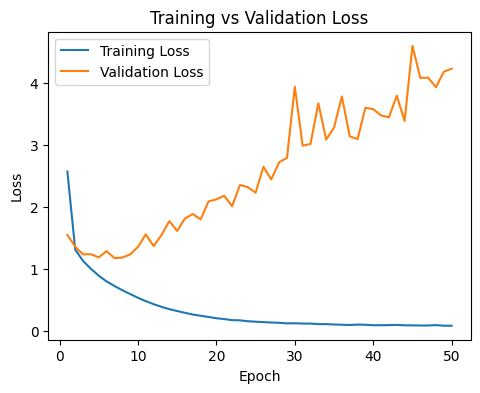

In [8]:
# Plot the loss curve
import matplotlib.pyplot as plt

epochs = range(1, len(values.history['loss']) + 1)

# Loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, values.history['loss'],     label='Training Loss')
plt.plot(epochs, values.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 4. Train (again) and evaluate the model (5 points)

- To this end, you have found the "best" hyper-parameters.
- Now, fix the hyper-parameters and train the network on the entire training set (all the 50K training samples)
- Evaluate your model on the test set.

### Train the model on the entire training set



In [9]:
x_train_full = np.concatenate((x_tr, x_val), axis=0)
y_train_full = np.concatenate((y_tr, y_val), axis=0)
print('Shape of x_train_full: ' + str(x_train_full.shape))
print('Shape of y_train_full: ' + str(y_train_full.shape))

Shape of x_train_full: (50000, 32, 32, 3)
Shape of y_train_full: (50000, 10)


In [10]:
#<Compile your model again (using the same hyper-parameters you tuned above)>
model.compile(optimizer = optimizers.RMSprop(learning_rate=0.0001), loss = 'categorical_crossentropy',
             metrics = ['accuracy'])

In [11]:
#<Train your model on the entire training set (50K samples)>
values = model.fit(x_train_full,y_train_full,batch_size = 20, epochs = 50, validation_data=(x_val,y_val))

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 0.8628 - loss: 0.7988 - val_accuracy: 0.6862 - val_loss: 2.1289
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - accuracy: 0.8811 - loss: 0.6081 - val_accuracy: 0.7256 - val_loss: 1.5277
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 149s 46ms/step - accuracy: 0.8945 - loss: 0.4987 - val_accuracy: 0.7274 - val_loss: 1.4531
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 135s 43ms/step - accuracy: 0.9054 - loss: 0.4187 - val_accuracy: 0.7911 - val_loss: 0.9096
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - accuracy: 0.9141 - loss: 0.3598 - val_accuracy: 0.8054 - val_loss: 0.8623
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 105s 42ms/step - accuracy: 0.9203 - loss: 0.3230 - val_accuracy: 0.7782 - val_loss: 0.9999
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 106s 42ms/step - accuracy: 0.9259 - loss: 0.2918 - val_accuracy: 0.8726 - val_loss: 0.5490
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 

## 5. Evaluate the model on the test set (5 points)

Do NOT used the test set until now. Make sure that your model parameters and hyper-parameters are independent of the test set.

In [12]:
# Evaluate your model performance (testing accuracy) on testing data.
test_loss, test_acc = model.evaluate(x_test, y_test_vec)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6530 - loss: 6.3855
Test Accuracy: 65.30%
Test Loss: 6.3855


## 6. Building model with new structure (25 points)
- In this section, you can build your model with adding new layers (e.g, BN layer or dropout layer, ...)
- If you want to regularize a ```Conv/Dense layer```, you should place a ```Dropout layer``` before the ```Conv/Dense layer```.
- You can try to compare their loss curve and testing accuracy and analyze your findings.
- You need to try at lease two different structures.

In [13]:
model2 = Sequential()
#Layer 1
model2.add(Conv2D(32, (3, 3), input_shape=(32, 32, 3)))
model2.add(BatchNormalization())
model2.add(Activation("relu"))
model2.add(MaxPooling2D(2, 2))
#Layer 2
model2.add(Conv2D(64, (4, 4)))
model2.add(Activation("relu"))
model2.add(MaxPooling2D(2, 2))
#FC Layer
model2.add(Flatten())
model2.add(Dense(256))
model2.add(BatchNormalization())
model2.add(Activation("relu"))
model2.add(Dense(10, activation="softmax"))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,530 (2.39 MB)

 Trainable params: 626,954 (2.39 MB)

 Non-trainable params: 576 (2.25 KB)

In [14]:
model2.compile(optimizer = optimizers.RMSprop(learning_rate=0.0001), loss = 'categorical_crossentropy',
             metrics = ['accuracy'])

In [15]:
values_model2 = model2.fit(x_train_full, y_train_full, batch_size=20, epochs=50)

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 127s 50ms/step - accuracy: 0.5206 - loss: 1.3565
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 122s 49ms/step - accuracy: 0.6517 - loss: 1.0071
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 124s 50ms/step - accuracy: 0.7016 - loss: 0.8631
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 123s 49ms/step - accuracy: 0.7369 - loss: 0.7666
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 125s 50ms/step - accuracy: 0.7667 - loss: 0.6844
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 142s 50ms/step - accuracy: 0.7928 - loss: 0.6179
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 125s 50ms/step - accuracy: 0.8115 - loss: 0.5591
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 123s 49ms/step - accuracy: 0.8327 - loss: 0.5056
Epoch 9/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 124s 49ms/step - accuracy: 0.8505 - loss: 0.4542
Epoch 10/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 144s 50ms/step - accuracy: 0.8642 - loss: 0.4138
Epoch 11/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 139s 49ms/step - accuracy: 0.8774 - loss: 0.37

In [16]:
test_loss, test_acc = model2.evaluate(x_test, y_test_vec)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6997 - loss: 1.4193
Test Accuracy: 69.97%
Test Loss: 1.4193


In [17]:
# Model 3 -> Added BatchNormalization in both the convolution layers, fully connected layer
# and dropout layer before the Conv/Dense layer to regularize.
model3 = Sequential()
#Layer 1
model3.add(Conv2D(32, (3, 3), input_shape=(32, 32, 3)))
model3.add(BatchNormalization())
model3.add(Activation("relu"))
model3.add(MaxPooling2D(2, 2))
#Layer 2
model3.add(Conv2D(64, (4, 4)))
model3.add(Activation("relu"))
model3.add(MaxPooling2D(2, 2))
#FC Layer
model3.add(Flatten())
model3.add(Dropout(0.5))
model3.add(Dense(256))
model3.add(BatchNormalization())
model3.add(Activation("relu"))
model3.add(Dense(10, activation="softmax"))

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,530 (2.39 MB)

 Trainable params: 626,954 (2.39 MB)

 Non-trainable params: 576 (2.25 KB)

In [18]:
model3.compile(optimizer = optimizers.RMSprop(learning_rate=0.0001), loss = 'categorical_crossentropy',
             metrics = ['accuracy'])

In [19]:
values_model3 = model3.fit(x_train_full, y_train_full, batch_size=20, epochs=50)

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 127s 50ms/step - accuracy: 0.4276 - loss: 1.6066
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 145s 51ms/step - accuracy: 0.5528 - loss: 1.2746
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 125s 50ms/step - accuracy: 0.5991 - loss: 1.1449
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 124s 50ms/step - accuracy: 0.6244 - loss: 1.0747
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 143s 50ms/step - accuracy: 0.6457 - loss: 1.0153
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 126s 50ms/step - accuracy: 0.6622 - loss: 0.9731
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 142s 50ms/step - accuracy: 0.6750 - loss: 0.9380
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 141s 50ms/step - accuracy: 0.6845 - loss: 0.9174
Epoch 9/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 125s 50ms/step - accuracy: 0.6923 - loss: 0.8889
Epoch 10/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 126s 50ms/step - accuracy: 0.7028 - loss: 0.8633
Epoch 11/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 124s 50ms/step - accuracy: 0.7071 - loss: 0.84

In [20]:
test_loss, test_acc = model3.evaluate(x_test, y_test_vec)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7616 - loss: 0.7516
Test Accuracy: 76.16%
Test Loss: 0.7516


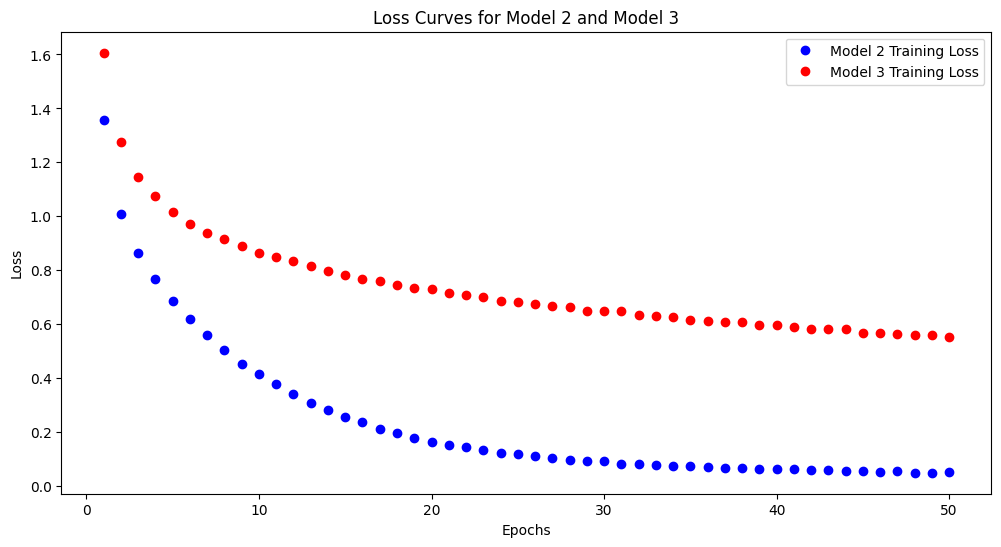

In [21]:
loss_model2 = values_model2.history['loss']
loss_model3 = values_model3.history['loss']
epochs = range(1, 51)
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_model2, 'bo', label='Model 2 Training Loss')
plt.plot(epochs, loss_model3, 'ro', label='Model 3 Training Loss')
plt.title('Loss Curves for Model 2 and Model 3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


*   Model 1 which is Baseline CNN we had Final Train Accuracy ~ 97.7% ,Test Accuracy 65.30% and Test Loss 6.39.
*   Model 2which is CNN + BatchNorm we had Final Train Accuracy ~ 98.5% ,Test Accuracy 69.97% and Test Loss 1.42
*   Model 3which is CNN + BatchNorm + Dropout we had Final Train Accuracy~81.3% ,Test Accuracy 76.16% and Test Loss 0.75

Overfitting gets worse as we train longer without regularisation (Model 1's val loss reaches 4.2 — which is  higher than its starting value)
BatchNorm alone reduces the damage but doesn't fully solve overfitting
BatchNorm + Dropout together provides strong regularisation — the model trades a lower apparent training accuracy for a much better real-world performance (+10.86% over the baseline)





